# Example 4.3: Finite element modeling of 2D frames


We will consider a simply supported glulam beam in this example. The beam is 4 meters long, 0.05 meters wide and 0.2 meters tall. The combined mass of the member and non-structural mass is 50 kg/m. Use two beam elements to model the beam, as shown in the figure below

<img src="./figures/Beam_simplysupport_2_elements.svg">

## Define the finite element model
We start by defining the nodes and the elements of the finite element model by defining an array of nodes where the first column contains the node numbers, the second the $x$ coordinates, and the last column contains the $z$ coordinates. We also define elements by an array where the first column contains the element numbers. The second includes the first node, and the third the second node, while the last column can be used to define the element type is the model consists of elements with different properties.

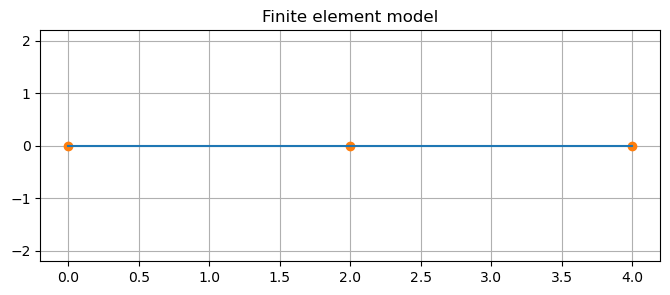

In [17]:
import numpy as np
from scipy import linalg as spla
from matplotlib import pyplot as plt

# Matrix with rows on the form [nodenumber,x,y]
nodes = np.array([
[1, 0, 0],
[2, 2, 0],
[3, 4, 0]],dtype=float)

# Matrix with rows on the form [elementnumber,nodenumber_start,nodenumber_end,element_type]
elements = np.array(
[[1, 1, 2, 1],
[2, 2, 3, 1]])

def plot_fe_model(nodes,elements):
    
    hor_size = np.max(nodes[:,1]) - np.min(nodes[:,1])
    hor_mid = 1/2*(np.max(nodes[:,1]) + np.min(nodes[:,1]))
    
    vert_size = np.max(nodes[:,2]) - np.min(nodes[:,2])
    vert_mid = 1/2*(np.max(nodes[:,2]) + np.min(nodes[:,2]))
    
    max_dim = np.max([hor_size,vert_size])*1.1
    
    plt.figure(figsize=(8,3))
    plt.title('Finite element model')
    plt.plot(nodes[:,1],nodes[:,2],"o",color="tab:orange")
    
    for k in range(elements.shape[0]):
        x1 = [nodes[nodes[:,0]==elements[k,1],1],nodes[nodes[:,0]==elements[k,2],1] ]
        x2 = [nodes[nodes[:,0]==elements[k,1],2],nodes[nodes[:,0]==elements[k,2],2] ]
        
        plt.plot(x1,x2,color="tab:blue")
        
    plt.xlim([hor_mid-max_dim/2, hor_mid+max_dim/2])
    plt.ylim([vert_mid-max_dim/2, vert_mid+max_dim/2])
    plt.grid()
    
    #for k in range(nodes.shape[0]):
        #plt.text(nodes[k,1],nodes[k,2], str(nodes[k,0]))

plot_fe_model(nodes,elements)


## Mass and stiffness matrices of a beam element in local and global coordinates

The beam element has six degrees of freedom, and the stiffness and mass matrices in the local coordinate system are defined by

<img src="./figures/Beam_element.svg">
                        
$$ \mathbf{k} = \left[ \begin{array}{cccccc} 
\dfrac{EA}{L} & 0 & 0 & -\dfrac{EA}{L} & 0 & 0 \\
0 & \dfrac{12EI}{L^3} & -\dfrac{6EI}{L^2} & 0 & -\dfrac{12EI}{L^3} & -\dfrac{6EI}{L^2} \\
0 & -\dfrac{6EI}{L^2} & \dfrac{4EI}{L} & 0 & \dfrac{6EI}{L^2} & \dfrac{2EI}{L} \\
-\dfrac{EA}{L} & 0 & 0 & \dfrac{EA}{L} & 0 & 0 \\
0 & -\dfrac{12EI}{L^3} & \dfrac{6EI}{L^2} & 0 & \dfrac{12EI}{L^3} & \dfrac{6EI}{L^2}  \\
0 & -\dfrac{6EI}{L^2}  & \dfrac{2EI}{L}  & 0 & \dfrac{6EI}{L^2}  & \dfrac{4EI}{L}  \\
\end{array}   \right]  $$


$$ \mathbf{m} = \dfrac{mL}{420} \left[ \begin{array}{cccccc} 
140 & 0 & 0 & 70 & 0 & 0 \\
0 & 156 & -22L & 0 & 54 & 13L \\
0 & -22L & 4L^2 & 0 & -13L & -3L^2 \\
70 & 0 & 0 & 140 & 0 & 0 \\
0 & 54 & -13L & 0 & 156 & 22L  \\
0 & 13L  & -3L^2  & 0 & 22L  & 4L^2 \\
\end{array}   \right]  $$

It is also necessary to obtain the stiffness and mass matrix for a beam element with an arbitrary orientation. This can be achieved by defining a transformation matrix between the local (beam element)
and the global coordinate system.

The transform can be defined considering the unit vectors defining the direction of the beam element.

<img src="./figures/Beam_element_rotated.svg">

$$ \bar{\mathbf{T}}_{G2L} = \left[ \begin{array}{ccc} \cos(\theta) & \sin(\theta) & 0 \\
                                                -\sin(\theta) & \cos(\theta) & 0 \\
                                                0 & 0 & 1\end{array}\right]  $$
                                                
The transformation matrix considering all degrees of freedom of the element, becomes



$$ \mathbf{T}_{G2L} = \left[ \begin{array}{ccc} \mathbf{T}_{G2L} & \mathbf{0} \\
                                                \mathbf{0}& \mathbf{T}_{G2L}\end{array}\right]  $$
                                                

$$ \mathbf{v}_{L} = \mathbf{T}_{G2L} \mathbf{v}_{G} $$
                                                
                                                
The stiffness and mass matrix for a beam element in global coordinates can be obtained by

$$ \mathbf{k}_G = \mathbf{T}^\text{T}_{G2L} \mathbf{k}_L \mathbf{T}_{G2L} $$

$$ \mathbf{m}_G = \mathbf{T}^\text{T}_{G2L} \mathbf{m}_L \mathbf{T}_{G2L} $$




In [18]:
def beam_element(E,A,I,mass_per_length,x1,x2):
    """
    Parameters
    ----------
    E : float
        Modulus of elasticity
    A : float
        Cross-sectional area
    I : float
        Second moment of area
    mass_per_length : float
        Mass per unit length
    x1 : float
        x, y coordinates of node 1
    x2 : float
        x, y coordinates of node 2

    Returns
    -------
    k_global : ndarray
        Element stiffness matrix in global coordinates
    m_global : ndarray
        Element mass matrix in global coordinates

    """
    L = ((x2-x1) @ (x2-x1))**0.5
    
    EA = E*A
    EI = E*I
    
    k_local = np.array([[EA/L, 0, 0, -EA/L, 0, 0],
                        [0, 12*EI/L**3, -6*EI/L**2, 0, -12*EI/L**3, -6*EI/L**2 ],
                        [0, -6*EI/L**2, 4*EI/L, 0, 6*EI/L**2, 2*EI/L],
                        [-EA/L, 0, 0, EA/L, 0, 0],
                        [0, -12*EI/L**3, 6*EI/L**2, 0, 12*EI/L**3, 6*EI/L**2],
                        [0, -6*EI/L**2, 2*EI/L, 0, 6*EI/L**2, 4*EI/L]])
    
    m_local = mass_per_length*L/420*np.array([[140, 0, 0, 70, 0, 0],
                        [0, 156, -22*L, 0, 54, 13*L],
                        [0, -22*L, 4*L**2, 0, -13*L, -3*L**2],
                        [70, 0, 0, 140, 0, 0],
                        [0, 54, -13*L, 0, 156, 22*L],
                        [0, 13*L, -3*L**2, 0, 22*L, 4*L**2]])
    
    e1 = (x2-x1)/L    
    e2 = np.cross(np.array([0, 0, 1]),np.append(e1,0))
    e2 = e2[0:-1]
    
    T_glob2loc = np.vstack((e1,e2))
    T_glob2loc = spla.block_diag(T_glob2loc,1.0)
    T_glob2loc_element = spla.block_diag(T_glob2loc,T_glob2loc)
    
     
    k_global = T_glob2loc_element.T @ k_local @ T_glob2loc_element
    m_global = T_glob2loc_element.T @ m_local @ T_glob2loc_element
    
    return k_global, m_global

## Mass and stiffness matrix of a system of beam elements

The assembly of the finite element model can be done straightforwardly by adding the contributions from each element to the system matrices. It is convenient to split the element matrices into four submatrices as follows.

$$ \mathbf{k}_G = \left[ \begin{array}{cc} \mathbf{k}_{11} & \mathbf{k}_{12} \\ \mathbf{k}_{21} & \mathbf{k}_{22}  \end{array}\right] $$

The figure below shows the system mass or stiffness matrix for an element model with ten nodes. As seen in the figure, ten nodes imply that there are ten sub-matrices. Each submatrix is 3x3 for the element that we are considering. Consider an element connected to nodes 3 and 7. The four submatrices are added to the system mass or stiffness matrix, as shown in the figure. All elements are added to the system mass and stiffness one by one, following the nodal connectivity. 
                     
<img src="./figures/Stiffness_matrix_assignment.svg">

We use a modulus of elasticity of $E=10\,000$ MPa, a rectangular cross-section that is 50 mm wide and 200 mm high, and a mass per unit length of 50 kg/m.

In [19]:
E = 1.0e10
A = 0.05*0.2
I = 1/12*0.05*0.2**3
mass_per_length = 50.0

dofs_in_nodes = 3

def assembly(nodes,elements,dofs_in_nodes,E,A,I,mass_per_length):
    M = np.zeros((nodes.shape[0]*dofs_in_nodes,nodes.shape[0]*dofs_in_nodes))
    K = np.zeros((nodes.shape[0]*dofs_in_nodes,nodes.shape[0]*dofs_in_nodes)) 
    
    for k in range(elements.shape[0]):
        node_idx1 = np.where(nodes[:,0]==elements[k,1])[0][0]
        node_idx2 = np.where(nodes[:,0]==elements[k,2])[0][0]   
        
        x1 = nodes[node_idx1,1:]
        x2 = nodes[node_idx2,1:]    
        
        k_global, m_global = beam_element(E,A,I,mass_per_length,x1,x2)
        
        K[dofs_in_nodes*node_idx1:dofs_in_nodes*(node_idx1+1),dofs_in_nodes*node_idx1:dofs_in_nodes*(node_idx1+1)] += k_global[0:dofs_in_nodes,0:dofs_in_nodes]
        K[dofs_in_nodes*node_idx1:dofs_in_nodes*(node_idx1+1),dofs_in_nodes*node_idx2:dofs_in_nodes*(node_idx2+1)] += k_global[0:dofs_in_nodes,dofs_in_nodes:] 
        K[dofs_in_nodes*node_idx2:dofs_in_nodes*(node_idx2+1),dofs_in_nodes*node_idx1:dofs_in_nodes*(node_idx1+1)] += k_global[dofs_in_nodes:,0:dofs_in_nodes] 
        K[dofs_in_nodes*node_idx2:dofs_in_nodes*(node_idx2+1),dofs_in_nodes*node_idx2:dofs_in_nodes*(node_idx2+1)] += k_global[dofs_in_nodes:,dofs_in_nodes:] 
        
        M[dofs_in_nodes*node_idx1:dofs_in_nodes*(node_idx1+1),dofs_in_nodes*node_idx1:dofs_in_nodes*(node_idx1+1)] += m_global[0:dofs_in_nodes,0:dofs_in_nodes]
        M[dofs_in_nodes*node_idx1:dofs_in_nodes*(node_idx1+1),dofs_in_nodes*node_idx2:dofs_in_nodes*(node_idx2+1)] += m_global[0:dofs_in_nodes,dofs_in_nodes:] 
        M[dofs_in_nodes*node_idx2:dofs_in_nodes*(node_idx2+1),dofs_in_nodes*node_idx1:dofs_in_nodes*(node_idx1+1)] += m_global[dofs_in_nodes:,0:dofs_in_nodes] 
        M[dofs_in_nodes*node_idx2:dofs_in_nodes*(node_idx2+1),dofs_in_nodes*node_idx2:dofs_in_nodes*(node_idx2+1)] += m_global[dofs_in_nodes:,dofs_in_nodes:] 
        
    return K, M

K, M = assembly(nodes,elements,dofs_in_nodes,E,A,I,mass_per_length)

print('Stiffness matrix K:')
print(np.array2string(K, precision=2, suppress_small=True, max_line_width=200))

print('Mass matrix M:')
print(np.array2string(M, precision=2, suppress_small=True, max_line_width=200))

Stiffness matrix K:
[[ 5.00e+07  0.00e+00  0.00e+00 -5.00e+07  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00]
 [ 0.00e+00  5.00e+05 -5.00e+05  0.00e+00 -5.00e+05 -5.00e+05  0.00e+00  0.00e+00  0.00e+00]
 [ 0.00e+00 -5.00e+05  6.67e+05  0.00e+00  5.00e+05  3.33e+05  0.00e+00  0.00e+00  0.00e+00]
 [-5.00e+07  0.00e+00  0.00e+00  1.00e+08  0.00e+00  0.00e+00 -5.00e+07  0.00e+00  0.00e+00]
 [ 0.00e+00 -5.00e+05  5.00e+05  0.00e+00  1.00e+06  0.00e+00  0.00e+00 -5.00e+05 -5.00e+05]
 [ 0.00e+00 -5.00e+05  3.33e+05  0.00e+00  0.00e+00  1.33e+06  0.00e+00  5.00e+05  3.33e+05]
 [ 0.00e+00  0.00e+00  0.00e+00 -5.00e+07  0.00e+00  0.00e+00  5.00e+07  0.00e+00  0.00e+00]
 [ 0.00e+00  0.00e+00  0.00e+00  0.00e+00 -5.00e+05  5.00e+05  0.00e+00  5.00e+05  5.00e+05]
 [ 0.00e+00  0.00e+00  0.00e+00  0.00e+00 -5.00e+05  3.33e+05  0.00e+00  5.00e+05  6.67e+05]]
Mass matrix M:
[[ 33.33   0.     0.    16.67   0.     0.     0.     0.     0.  ]
 [  0.    37.14 -10.48   0.    12.86   6.19   0.     0.     0

## Boundary conditions

There are several ways to introduce boundary conditions to the finite element model. A straightforward alternative is to introduce the degrees of freedom by kinematic condensation.

$$ \underbrace{\mathbf{v}}_{\substack{\text{All} \\ \text{DOFs}}} = \underbrace{\mathbf{T}_{BC}}_{\substack{\text{Constraint} \\ \text{matrix}}} \:\: \underbrace{\mathbf{v}_{BC}}_{\substack{\text{Independent} \\ \text{DOFs}}} $$

We can start by defining the transformation matrix as the identity matrix and then delete all columns corresponding to constrained degrees of freedom. If kinematic constraints are formed by relations between the degrees of freedom, which might be the case if boundary conditions that do not follow the global coordinate system are introduced. The system matrices for the constrained finite element model can be obtained by

$$ \mathbf{K}_{BC} = \mathbf{T}^\text{T}_{BC} \mathbf{K} \mathbf{T}_{BC} $$


The beam we consider is simply supported at the left end, which gives the constraints

$$ v_1 = 0, \qquad v_2 = 0 $$

There is a roller bearing at the other end, but it is not aligned with the global coordinate system. The roller bearing introduces the following relation between the degrees of freedom:

$$ \dfrac{v_8}{v_7} = \tan{\theta} \rightarrow v_7 = \frac{1}{\tan{\theta}} v_8 $$

<img src="./figures/Beam_simplysupport_2_elements.svg">

The equations describing the kinematic constraints are thus defined by

$$ \left[ \begin{array}{c} v_1  \\ v_2  \\ v_3  \\ v_4  \\ v_5  \\ v_6  \\ v_7 \\ v_8  \\ v_9 \end{array} \right] =
\left[ \begin{array}{ccccccc} 0 & 0 & 0 & 0 & 0 & 0  \\
                                                 0 & 0 & 0 & 0 & 0 & 0  \\
                                                 1 & 0 & 0 & 0 & 0 & 0  \\
                                                 0 & 1 & 0 & 0 & 0 & 0 \\
                                                 0 & 0 & 1 & 0 & 0 & 0\\
                                                 0 & 0 & 0 & 1 & 0 & 0 \\
                                                 0 & 0 & 0 & 0 & 1/\tan{\theta} & 0 \\
                                                 0 & 0 & 0 & 0 & 1 & 0 \\
                                                 0 & 0 & 0 & 0 & 0 & 1
                                                 \end{array}\right] 
                                                 \left[ \begin{array}{c} v_3  \\ v_4  \\ v_5  \\ v_6 \\ v_8 \\ v_9 \end{array} \right] $$
                                                 

In [20]:
T_BC = np.eye(nodes.shape[0]*dofs_in_nodes)
T_BC[6,7] = 1.0/(np.tan(np.pi/4))  # remember that the first index is 0!
T_BC = np.delete(T_BC,[0, 1 , dofs_in_nodes*2],axis=1)

K_bc = T_BC.T @ K @ T_BC
M_bc = T_BC.T @ M @ T_BC

## Modes and frequencies
The natural frequencies and the modes of the constrained model can be obtained by solving the eigenvalue problem

In [21]:
omega_n_squared, Phi_bc = spla.eigh(K_bc, M_bc)
omega_n = np.sqrt(omega_n_squared)
f = omega_n / (2*np.pi)

print('Natural frequencies in Hz:')
print(f[0:5])

Natural frequencies in Hz:
[  8.03082696  35.15415177  77.72082632  99.07930945 164.75934124]


We can then plot the vibration modes. We first transform back to the full list of DOFs: $ \mathbf{v} = \mathbf{T}_{BC} \mathbf{v}_{BC}  $



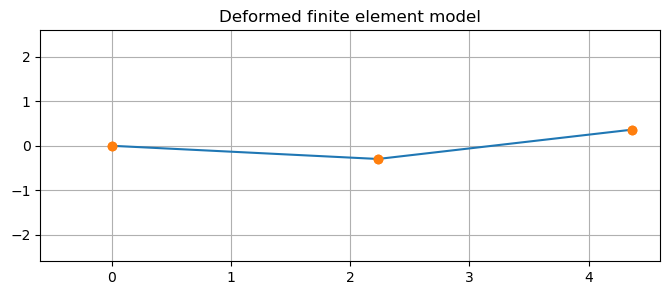

In [23]:
mode_idx = 2
phi_plot = T_BC @ Phi_bc[:,mode_idx]

plot_scale = 5

def plot_deformed_model(nodes,elements,phi_plot,plot_scale):
    
    hor_size = np.max(nodes[:,1]) - np.min(nodes[:,1])
    hor_mid = 1/2*(np.max(nodes[:,1]) + np.min(nodes[:,1]))
    
    vert_size = np.max(nodes[:,2]) - np.min(nodes[:,2])
    vert_mid = 1/2*(np.max(nodes[:,2]) + np.min(nodes[:,2]))
    
    max_dim = np.max([hor_size,vert_size])*1.3

    nodes_deformed = np.copy(nodes)
    nodes_deformed[:,1] = nodes_deformed[:,1]+plot_scale*phi_plot[0::3]
    nodes_deformed[:,2] = nodes_deformed[:,2]+plot_scale*phi_plot[1::3]
    plt.figure(figsize=(8,3))
    plt.title('Deformed finite element model')
    for k in range(elements.shape[0]):
        x1 = [nodes_deformed[nodes_deformed[:,0]==elements[k,1],1],nodes_deformed[nodes_deformed[:,0]==elements[k,2],1] ]
        x2 = [nodes_deformed[nodes_deformed[:,0]==elements[k,1],2],nodes_deformed[nodes_deformed[:,0]==elements[k,2],2] ]
        
        plt.plot(x1,x2,color="tab:blue")
    plt.plot(nodes[:,1]+plot_scale*phi_plot[0::3],nodes[:,2]+plot_scale*phi_plot[1::3],"o",color="tab:orange")
    plt.plot(nodes_deformed[:,1],nodes_deformed[:,2],"o",color="tab:orange")
    
    plt.xlim([hor_mid-max_dim/2, hor_mid+max_dim/2])
    plt.ylim([vert_mid-max_dim/2, vert_mid+max_dim/2])
    plt.grid()

plot_deformed_model(nodes,elements,phi_plot,plot_scale)

## Refine element model
Two elements already approximate the first frequency well, but additional elements are needed to represent higher modes accurately. The element model is refined by splitting the elements. New nodes are appended to the existing node array, and the element connectivity is then redefined.

Natural frequencies in Hz:
[  7.99935189  31.76447576  68.81017387  87.26977573 130.12639696]


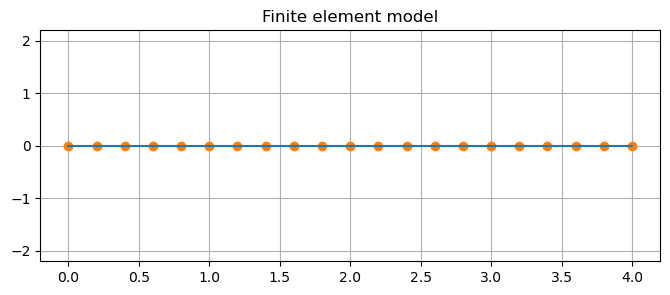

In [28]:
element_refine_factor = 10

def refine_mesh(nodes,elements,T_BC,element_refine_factor,dofs_in_nodes):

    nodes_add = np.zeros(((element_refine_factor-1)*elements.shape[0],3))    
    nodes_add[:,0] = np.arange(0,nodes_add.shape[0])+ 10000
    new_nodes_element = element_refine_factor-1
    
    T_bc_refined = spla.block_diag(T_BC,np.eye(nodes_add.shape[0]*dofs_in_nodes))
        
    refined_elements = np.zeros((element_refine_factor * elements.shape[0],3))    
    refined_elements[:,0] = np.arange(1,elements.shape[0]*element_refine_factor+1)    
    
    for k in range(elements.shape[0]):
        
        refined_elements[k*element_refine_factor:(k+1)*element_refine_factor,1] = np.hstack((elements[k,1], np.arange(k*new_nodes_element,(k+1)*new_nodes_element) +10000))
        refined_elements[k*element_refine_factor:(k+1)*element_refine_factor,2] = np.hstack(( np.arange(k*new_nodes_element,(k+1)*new_nodes_element) +10000, elements[k,2]))
        
        
        node_idx1 = np.where(nodes[:,0]==elements[k,1])[0][0]
        node_idx2 = np.where(nodes[:,0]==elements[k,2])[0][0] 
        
        x1 = nodes[node_idx1,1:]
        x2 = nodes[node_idx2,1:] 
        
        nodes_add[k*new_nodes_element:(k+1)*new_nodes_element,1] = np.linspace(x1[0],x2[0],element_refine_factor+1)[1:-1]
        nodes_add[k*new_nodes_element:(k+1)*new_nodes_element,2] = np.linspace(x1[1],x2[1],element_refine_factor+1)[1:-1]
    
    refined_nodes = np.vstack((nodes,nodes_add))
    
    return refined_nodes, refined_elements, T_bc_refined

refined_nodes, refined_elements, T_bc_refined = refine_mesh(nodes,elements,T_BC,element_refine_factor,dofs_in_nodes)
    

plot_fe_model(refined_nodes,refined_elements)

K_refined, M_refined = assembly(refined_nodes,refined_elements,dofs_in_nodes,E,A,I,mass_per_length)

K_bc_refined = T_bc_refined.T @ K_refined @ T_bc_refined
M_bc_refined = T_bc_refined.T @ M_refined @ T_bc_refined

omega_n_squared, Phi_bc = spla.eigh(K_bc_refined, M_bc_refined)
omega_n = np.sqrt(omega_n_squared)
f = omega_n / (2*np.pi)

print('Natural frequencies in Hz:')
print(f[0:5])

With the refined finite element model, the mode shapes are represented by more degrees of freedom and are therefore better resolved. This is particularly important for the higher modes. The lowest modes change relatively little, indicating that the coarse model already provides a reasonable approximation of the low-frequency behavior.

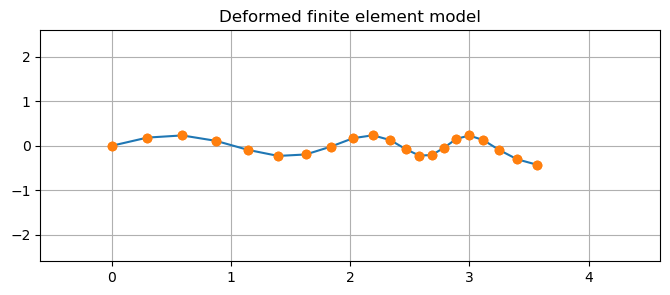

In [34]:
mode_idx = 6
phi_plot = T_bc_refined @ Phi_bc[:,mode_idx]

plot_scale = 5

plot_deformed_model(refined_nodes,refined_elements,phi_plot,plot_scale)